In [12]:
import pandas as pd

# Datos reales simplificados (todos casos de impago)
datos_reales = pd.DataFrame([
    {'ID': 'P003', 'Monto Préstamo (€)': 5000, 'Tasa Interés (%)': 12.0, 'Historial Pagos (0-5)': 1,
     'Ingresos Anuales (€)': 28000, 'Días Atraso Últ. Pago': 45, 'Impago (Sí/No)': 'Sí'},
    {'ID': 'P005', 'Monto Préstamo (€)': 9000, 'Tasa Interés (%)': 10.5, 'Historial Pagos (0-5)': 2,
     'Ingresos Anuales (€)': 35000, 'Días Atraso Últ. Pago': 60, 'Impago (Sí/No)': 'Sí'},
    {'ID': 'P009', 'Monto Préstamo (€)': 6500, 'Tasa Interés (%)': 11.5, 'Historial Pagos (0-5)': 1,
     'Ingresos Anuales (€)': 32000, 'Días Atraso Últ. Pago': 50, 'Impago (Sí/No)': 'Sí'},
    {'ID': 'P014', 'Monto Préstamo (€)': 7000, 'Tasa Interés (%)': 11.0, 'Historial Pagos (0-5)': 1,
     'Ingresos Anuales (€)': 29000, 'Días Atraso Últ. Pago': 65, 'Impago (Sí/No)': 'Sí'},
    {'ID': 'P018', 'Monto Préstamo (€)': 9500, 'Tasa Interés (%)': 10.0, 'Historial Pagos (0-5)': 2,
     'Ingresos Anuales (€)': 37000, 'Días Atraso Últ. Pago': 40, 'Impago (Sí/No)': 'Sí'}
])


In [13]:


from ctgan import CTGAN
import pandas as pd

# Datos semilla
data = pd.DataFrame({
    "edad": [34, 28, 45, 39, 30],
    "pais": ["DE", "FR", "DE", "ES", "ES"],
    "ingresos_mensuales": [2500, 2100, 3200, 2800, 2300],
    "tipo_cliente": ["nuevo", "nuevo", "fidelizado", "fidelizado", "nuevo"]
})

categorical = ["pais", "tipo_cliente"]

# Entrenamiento
ctgan = CTGAN(epochs=300)
ctgan.fit(data, categorical)

# ✅ Generación condicional CORRECTA
synthetic = ctgan.sample(10, "pais", "DE")

print("Datos sintéticos generados (condición: pais='DE'):")
print(synthetic)

Datos sintéticos generados (condición: pais='DE'):
   edad pais  ingresos_mensuales tipo_cliente
0    35   DE                1418   fidelizado
1    25   FR                2405        nuevo
2    18   DE                3146        nuevo
3    30   DE                2983        nuevo
4    16   ES                2403   fidelizado
5    48   FR                1722        nuevo
6    47   ES                3141        nuevo
7    49   DE                3606   fidelizado
8    15   DE                2134   fidelizado
9    38   ES                2626        nuevo


In [14]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
import pandas as pd

# Preprocesar datos
datos_reales_ctgan = datos_reales.drop(columns=['ID']).copy()

# Crear metadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(datos_reales_ctgan)

# Crear modelo
modelo_ctgan = CTGANSynthesizer(
    metadata=metadata,
    epochs=500
)

# Entrenar
modelo_ctgan.fit(datos_reales_ctgan)

# Generar datos
datos_sinteticos = modelo_ctgan.sample(100)

print(datos_sinteticos.head())


c:\Users\Jorge alberto\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sdv\single_table\base.py:168: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
c:\Users\Jorge alberto\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sdv\single_table\base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


   Monto Préstamo (€)  Tasa Interés (%)  Historial Pagos (0-5)  \
0                6624              11.5                      2   
1                8116              10.5                      1   
2                8081              11.5                      1   
3                7446              10.8                      2   
4                5409              12.0                      2   

   Ingresos Anuales (€)  Días Atraso Últ. Pago Impago (Sí/No)  
0                 35495                     40             Sí  
1                 32620                     49             Sí  
2                 31916                     53             Sí  
3                 32326                     53             Sí  
4                 36534                     46             Sí  


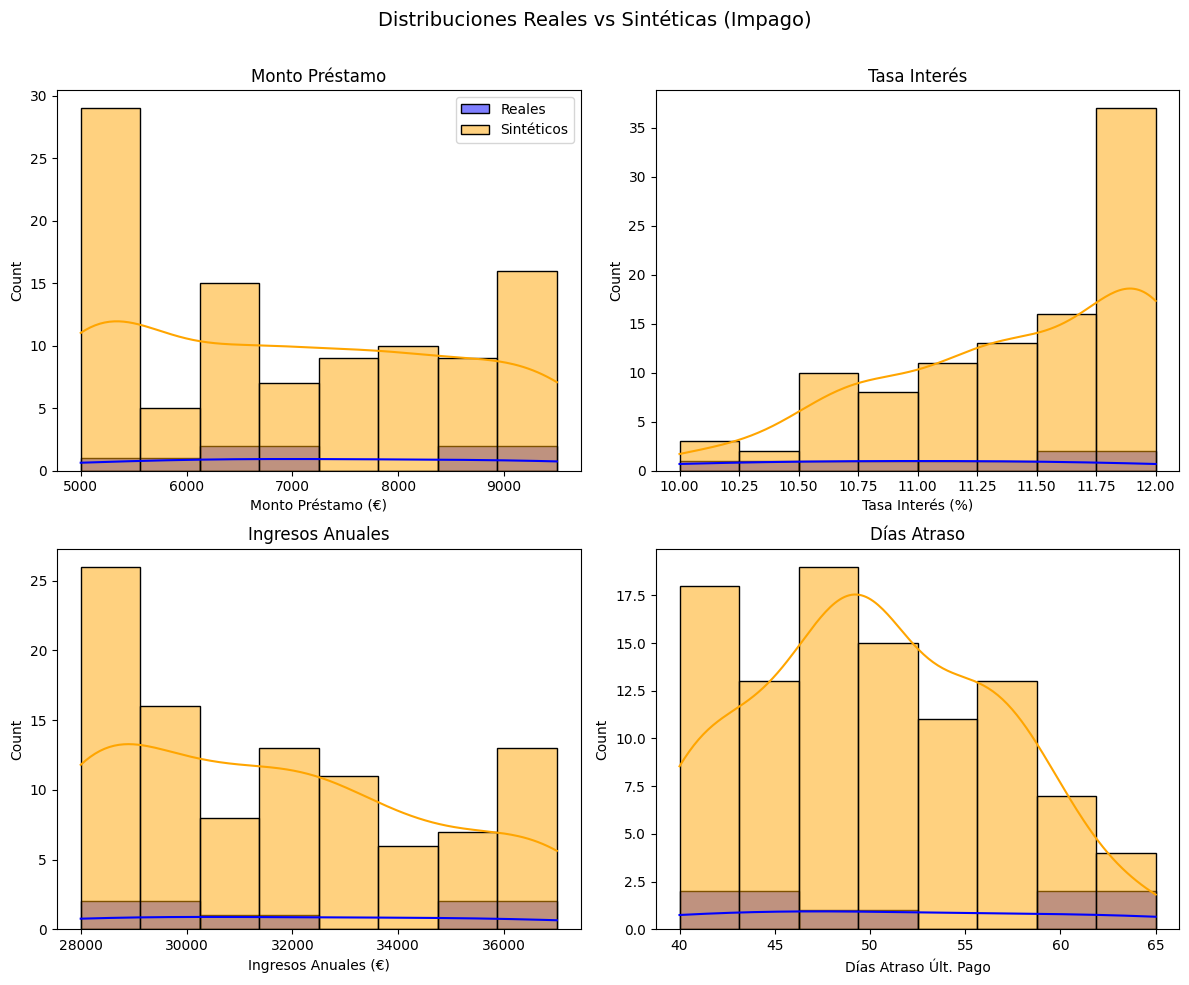

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Comparar variables clave entre reales y sintéticos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribuciones Reales vs Sintéticas (Impago)', fontsize=14)

# Monto
sns.histplot(datos_reales['Monto Préstamo (€)'], kde=True, color='blue', ax=axes[0, 0], label='Reales')
sns.histplot(datos_sinteticos['Monto Préstamo (€)'], kde=True, color='orange', ax=axes[0, 0], label='Sintéticos')
axes[0, 0].set_title('Monto Préstamo')
axes[0, 0].legend()

# Tasa
sns.histplot(datos_reales['Tasa Interés (%)'], kde=True, color='blue', ax=axes[0, 1])
sns.histplot(datos_sinteticos['Tasa Interés (%)'], kde=True, color='orange', ax=axes[0, 1])
axes[0, 1].set_title('Tasa Interés')

# Ingresos
sns.histplot(datos_reales['Ingresos Anuales (€)'], kde=True, color='blue', ax=axes[1, 0])
sns.histplot(datos_sinteticos['Ingresos Anuales (€)'], kde=True, color='orange', ax=axes[1, 0])
axes[1, 0].set_title('Ingresos Anuales')

# Atrasos
sns.histplot(datos_reales['Días Atraso Últ. Pago'], kde=True, color='blue', ax=axes[1, 1])
sns.histplot(datos_sinteticos['Días Atraso Últ. Pago'], kde=True, color='orange', ax=axes[1, 1])
axes[1, 1].set_title('Días Atraso')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()